# Рекуррентные нейронные сети

## Подготовка данных

1) Подключение необходимых библиотек

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn torch

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Настройка отображения графиков
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Проверка доступности GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Используемое устройство: cpu


2) Загрузка данных

In [3]:
# Загрузка локального файла
df = pd.read_csv('Apol.csv', parse_dates=['Date'])

In [4]:
print(df.dtypes['Date'])

datetime64[us]


In [5]:
# Базовая информация
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок")
print(f"Период: {df['Date'].min()} — {df['Date'].max()}")
print(f"\nПервые 5 строк:")
print(df.head())

print(f"\nПропущенные значения:\n{df.isnull().sum()}")

# Статистика по переменной Adj Close
print(f"\nСтатистика 'Adj Close':")
print(df['Adj Close'].describe())

Размер датасета: 10458 строк, 7 колонок
Период: 1980-12-12 00:00:00 — 2022-06-03 00:00:00

Первые 5 строк:
        Date      Open      High       Low     Close  Adj Close     Volume
0 1980-12-12  0.128348  0.128906  0.128348  0.128348   0.100178  469033600
1 1980-12-15  0.122210  0.122210  0.121652  0.121652   0.094952  175884800
2 1980-12-16  0.113281  0.113281  0.112723  0.112723   0.087983  105728000
3 1980-12-17  0.115513  0.116071  0.115513  0.115513   0.090160   86441600
4 1980-12-18  0.118862  0.119420  0.118862  0.118862   0.092774   73449600

Пропущенные значения:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Статистика 'Adj Close':
count    10458.000000
mean        14.011578
std         31.417195
min          0.038329
25%          0.235319
50%          0.390838
75%         12.615027
max        181.511703
Name: Adj Close, dtype: float64


3) Визуализация

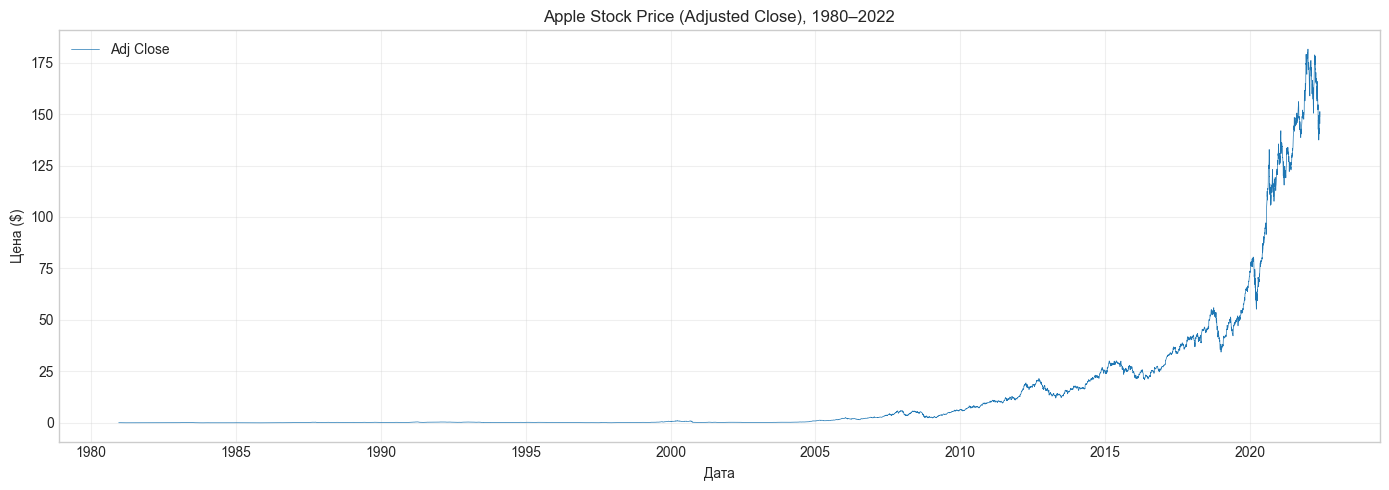

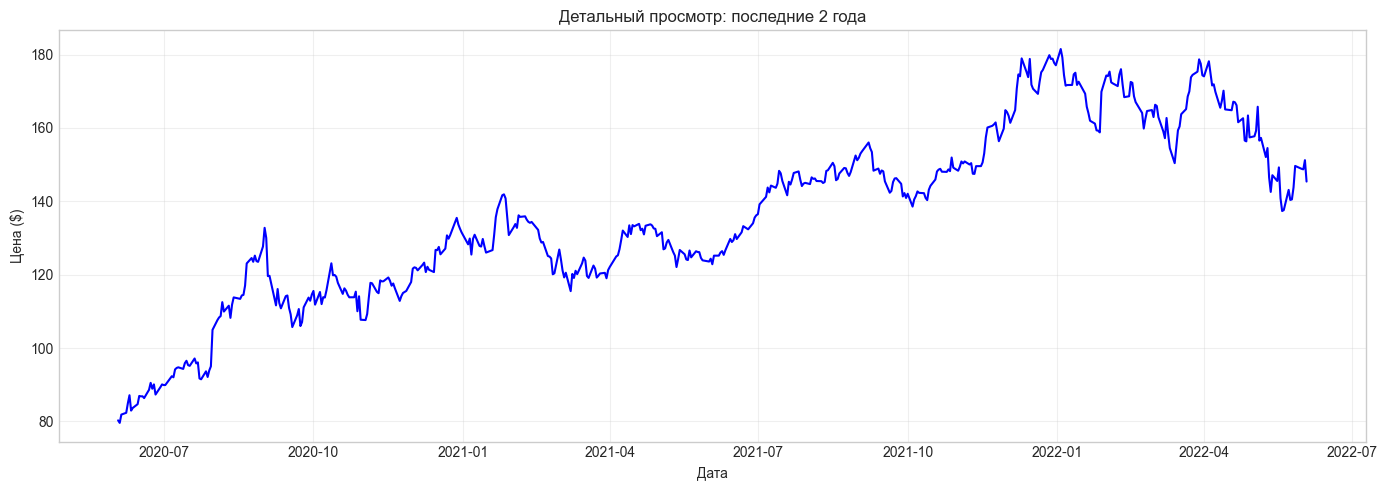

In [6]:
# График цены закрытия за весь период
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Adj Close'], linewidth=0.5, label='Adj Close')
plt.title('Apple Stock Price (Adjusted Close), 1980–2022')
plt.xlabel('Дата')
plt.ylabel('Цена ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# График за последние 2 года (для детального рассмотрения)
recent_df = df[df['Date'] >= df['Date'].max() - pd.Timedelta(days=730)].copy()
plt.figure(figsize=(14, 5))
plt.plot(recent_df['Date'], recent_df['Adj Close'], linewidth=1.5, color='blue')
plt.title('Детальный просмотр: последние 2 года')
plt.xlabel('Дата')
plt.ylabel('Цена ($)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

4) Подготовка данных

In [7]:
# 1. Установка даты как индекса и сортировка
df = df.set_index('Date').sort_index()

# 2. Выбор колонок для работы
features = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
df = df[features].copy()

# 3. Создание целевой переменной
df['target'] = np.log(df['Adj Close'].shift(-1) / df['Adj Close'])
df = df.dropna()

# 4. Создание лаговых признаков (исторические значения)
lag_periods = [1, 2, 3, 5, 10]
for lag in lag_periods:
    df[f'lag_{lag}'] = df['Adj Close'].shift(lag)

# 5. Скользящие статистики (технические индикаторы)
df['ma_7'] = df['Adj Close'].rolling(window=7).mean()   # Недельное среднее
df['ma_21'] = df['Adj Close'].rolling(window=21).mean() # Месячное среднее
df['volatility_5'] = df['Adj Close'].rolling(window=5).std()  # Волатильность

# 6. Доходность
df['log_return'] = np.log(df['Adj Close'] / df['Adj Close'].shift(1))

# 7. Временные признаки
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['quarter'] = df.index.quarter

# 8. Циклическое кодирование (sin/cos) для дней недели и месяцев
df['sin_day'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['cos_day'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)

# 9. Удаление строк с NaN после создания признаков
df = df.dropna().copy()

print(f"После предобработки: {df.shape[0]} строк, {df.shape[1]} признаков")
print(f"Признаки: {list(df.columns)}")

После предобработки: 10437 строк, 23 признаков
Признаки: ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'target', 'lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_10', 'ma_7', 'ma_21', 'volatility_5', 'log_return', 'day_of_week', 'month', 'quarter', 'sin_day', 'cos_day', 'sin_month', 'cos_month']


In [8]:
print(df.head())

                Open      High       Low     Close  Adj Close    Volume  \
Date                                                                      
1981-01-13  0.136719  0.136719  0.136161  0.136161   0.106277  23049600   
1981-01-14  0.136719  0.137277  0.136719  0.136719   0.106712  14291200   
1981-01-15  0.139509  0.140625  0.139509  0.139509   0.108890  14067200   
1981-01-16  0.138951  0.138951  0.138393  0.138393   0.108019  13395200   
1981-01-19  0.146763  0.147321  0.146763  0.146763   0.114552  41574400   

              target     lag_1     lag_2     lag_3  ...     ma_21  \
Date                                                ...             
1981-01-13  0.004085  0.110196  0.111068  0.105406  ...  0.108081   
1981-01-14  0.020205  0.106277  0.110196  0.111068  ...  0.108392   
1981-01-15 -0.008031  0.106712  0.106277  0.110196  ...  0.109056   
1981-01-16  0.058722  0.108890  0.106712  0.106277  ...  0.110010   
1981-01-19 -0.030886  0.108019  0.108890  0.106712  ...  0.1

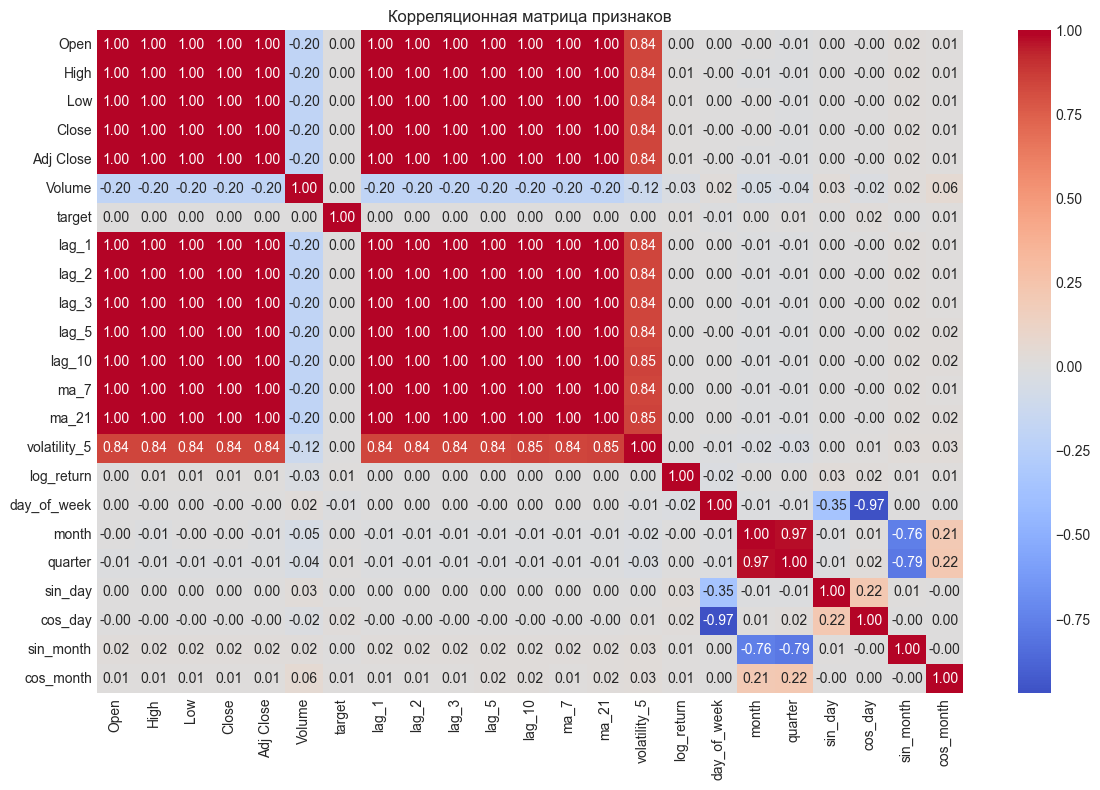

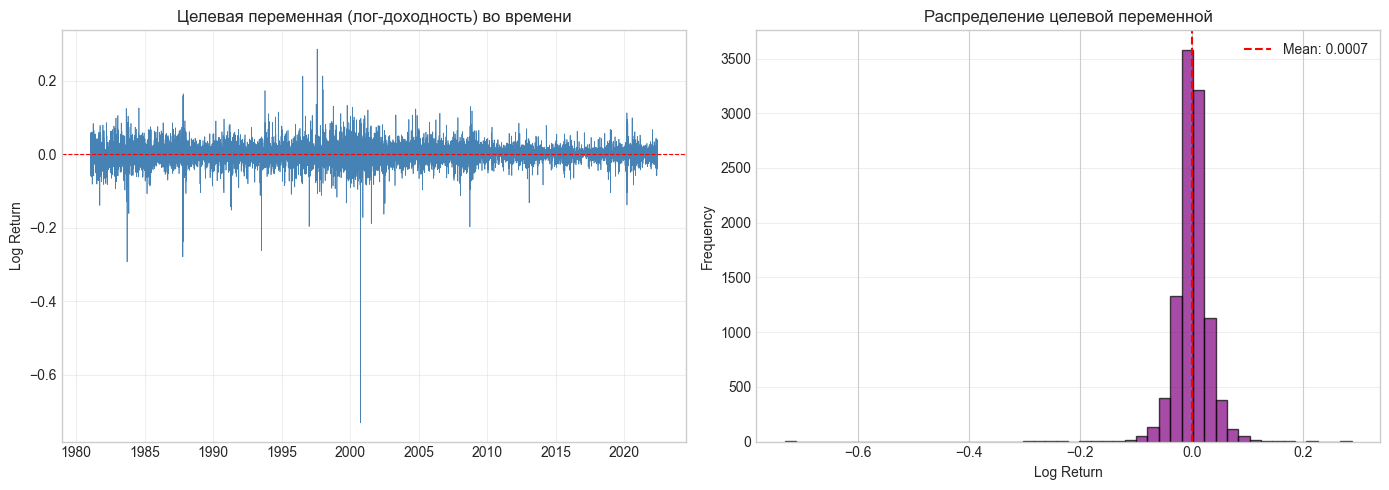

In [31]:
# Корреляционная матрица
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr().round(2)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# === ГРАФИК 1: Целевая переменная во времени ===
axes[0].plot(df.index, df['target'], linewidth=0.5, color='steelblue')
axes[0].set_title('Целевая переменная (лог-доходность) во времени')
axes[0].set_ylabel('Log Return')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)

# === ГРАФИК 2: Распределение целевой переменной ===
axes[1].hist(df['target'], bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[1].axvline(df['target'].mean(), color='red', linestyle='--', 
                label=f'Mean: {df["target"].mean():.4f}')
axes[1].set_title('Распределение целевой переменной')
axes[1].set_xlabel('Log Return')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

5) Разбиение и масштабирование

In [10]:
# 1. Разделение на признаки и целевую переменную
X = df.drop(columns=['target'])
y = df[['target']]

print(f"X shape: {X.shape}, y shape: {y.shape}")

# 2. Разбиение: 70% train, 15% val, 15% test
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train, X_val, X_test = X[:train_size], X[train_size:train_size+val_size], X[train_size+val_size:]
y_train, y_val, y_test = y[:train_size], y[train_size:train_size+val_size], y[train_size+val_size:]

print(f"Разбиение:")
print(f"   Train: {len(X_train)} строк ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Val:   {len(X_val)} строк ({len(X_val)/len(X)*100:.1f}%)")
print(f"   Test:  {len(X_test)} строк ({len(X_test)/len(X)*100:.1f}%)")

# 3. Масштабирование
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler(feature_range=(-1, 1))

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled = scaler_y.transform(y_val)
y_test_scaled = scaler_y.transform(y_test)

print("Масштабирование выполнено: X → [0, 1], y → [-1, 1]")

X shape: (10437, 22), y shape: (10437, 1)
Разбиение:
   Train: 7305 строк (70.0%)
   Val:   1565 строк (15.0%)
   Test:  1567 строк (15.0%)
Масштабирование выполнено: X → [0, 1], y → [-1, 1]


In [11]:
# Параметр последовательности
SEQ_LENGTH = 3

X_train_scaled = X_train_scaled.astype(np.float32)
y_train_scaled = y_train_scaled.astype(np.float32)
X_val_scaled = X_val_scaled.astype(np.float32)
y_val_scaled = y_val_scaled.astype(np.float32)
X_test_scaled = X_test_scaled.astype(np.float32)
y_test_scaled = y_test_scaled.astype(np.float32)

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, seq_length=SEQ_LENGTH):
        self.X = X
        self.y = y
        self.seq_length = seq_length

    def __len__(self):
        return len(self.X) - self.seq_length

    def __getitem__(self, idx):
        x_seq = self.X[idx : idx + self.seq_length]
        y_val = self.y[idx + self.seq_length]
        return x_seq, y_val

# Создание датасетов
train_dataset = TimeSeriesDataset(X_train_scaled, y_train_scaled, seq_length=5)
val_dataset   = TimeSeriesDataset(X_val_scaled, y_val_scaled, seq_length=5)
test_dataset  = TimeSeriesDataset(X_test_scaled, y_test_scaled, seq_length=5)

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoader создан: batch_size={BATCH_SIZE}, seq_length={SEQ_LENGTH}")
print(f"Батчей в эпохе: train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}")

DataLoader создан: batch_size=64, seq_length=3
Батчей в эпохе: train=115, val=25, test=25


## Реализация архитектур

In [12]:
import torch
import torch.nn as nn

1) RNN_Deep_ReLU (Глубина + Нелинейность)

In [13]:
class RNN_Deep_ReLU(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, layer_dim=2, output_dim=1, dropout=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        # dropout в nn.RNN применяется только между слоями (при layer_dim > 1)
        self.rnn = nn.RNN(input_dim, hidden_dim, layer_dim, batch_first=True, dropout=dropout)
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.fc2 = nn.Linear(32, output_dim)
        self.act = nn.ReLU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        if x.dim() == 2: x = x.unsqueeze(1)  # [batch, features] -> [batch, 1, features]
        h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim, device=x.device)
        out, _ = self.rnn(x, h0.detach())     # detach обрывает граф между батчами (Truncated BPTT)
        out = out[:, -1, :]                   # берём последний шаг
        out = self.act(self.drop(self.fc1(out)))
        return self.fc2(out)

2) RNN_BN_Leaky (Стабильность)

In [14]:
class RNN_BN_Leaky(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, layer_dim=1, output_dim=1, dropout=0.15):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.rnn = nn.RNN(input_dim, hidden_dim, layer_dim, batch_first=True)
        self.bn = nn.BatchNorm1d(hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.act = nn.LeakyReLU(0.1)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        if x.dim() == 2: x = x.unsqueeze(1)
        h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim, device=x.device)
        out, _ = self.rnn(x, h0.detach())
        out = out[:, -1, :]
        out = self.bn(out)                    # нормализуем выходы RNN
        out = self.act(self.drop(out))        # LeakyReLU + Dropout
        return self.fc(out)

3) RNN_ELU_Dropout (Сглаживание + Регуляризация)

In [15]:
class RNN_ELU_Dropout(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, layer_dim=1, output_dim=1, dropout=0.3):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.rnn = nn.RNN(input_dim, hidden_dim, layer_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.act = nn.ELU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        if x.dim() == 2: x = x.unsqueeze(1)
        h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim, device=x.device)
        out, _ = self.rnn(x, h0.detach())
        out = out[:, -1, :]
        out = self.act(self.drop(out))        # ELU сглаживает отрицательные значения
        return self.fc(out)

4) RNN_Wide (Емкость памяти)

In [16]:
class RNN_Wide(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, layer_dim=1, output_dim=1, dropout=0.1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.rnn = nn.RNN(input_dim, hidden_dim, layer_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        if x.dim() == 2: x = x.unsqueeze(1)
        h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim, device=x.device)
        out, _ = self.rnn(x, h0.detach())
        out = out[:, -1, :]
        return self.fc(self.drop(out))

5) Классическая RNN

In [17]:
class RNN_Classic(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, layer_dim=1, output_dim=1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.rnn = nn.RNN(input_dim, hidden_dim, layer_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        if x.dim() == 2: x = x.unsqueeze(1)
        h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim, device=x.device)
        out, _ = self.rnn(x, h0.detach())
        return self.fc(out[:, -1, :])

6) Классическая LSTM

In [18]:
class LSTM_Classic(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, layer_dim=1, output_dim=1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        if x.dim() == 2: x = x.unsqueeze(1)
        h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim, device=x.device)
        c0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim, device=x.device)
        out, _ = self.lstm(x, (h0.detach(), c0.detach()))
        return self.fc(out[:, -1, :])

7) Классическая GRU

In [19]:
class GRU_Classic(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, layer_dim=1, output_dim=1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.gru = nn.GRU(input_dim, hidden_dim, layer_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        if x.dim() == 2: x = x.unsqueeze(1)
        h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim, device=x.device)
        out, _ = self.gru(x, h0.detach())
        return self.fc(out[:, -1, :])

8) Residual RNN (с пропускным соединением)

In [20]:
class RNN_Residual(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, layer_dim=1, output_dim=1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.rnn = nn.RNN(input_dim, hidden_dim, layer_dim, batch_first=True)
        # Проекция входа, чтобы размерность совпадала с выходом RNN для сложения
        self.shortcut = nn.Linear(input_dim, hidden_dim) 
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        if x.dim() == 2: x = x.unsqueeze(1)
        h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim, device=x.device)
        rnn_out, _ = self.rnn(x, h0.detach())
        rnn_out = rnn_out[:, -1, :]
        
        # Skip connection: Вход проецируем и складываем с выходом RNN
        shortcut_out = self.shortcut(x[:, -1, :]) 
        out = rnn_out + shortcut_out 
        
        return self.fc(out)

In [21]:
input_dim = 22  # Количество признаков после Feature Engineering

models = {
    # 4 Собственные архитектуры
    "Deep_ReLU": RNN_Deep_ReLU(input_dim=input_dim).to(device),
    "BN_Leaky":  RNN_BN_Leaky(input_dim=input_dim).to(device),
    "ELU_Drop":  RNN_ELU_Dropout(input_dim=input_dim).to(device),
    "Wide":      RNN_Wide(input_dim=input_dim).to(device),
    "Residual": RNN_Residual(input_dim=input_dim).to(device),
    
    # 3 Классические архитектуры
    "RNN_Std":   RNN_Classic(input_dim=input_dim).to(device),
    "LSTM_Std":  LSTM_Classic(input_dim=input_dim).to(device),
    "GRU_Std":   GRU_Classic(input_dim=input_dim).to(device)
}

# Проверка количества параметров
print("Количество параметров в моделях:")
for name, model in models.items():
    params = sum(p.numel() for p in model.parameters())
    print(f"{name}: {params:,} параметров")

Количество параметров в моделях:
Deep_ReLU: 16,065 параметров
BN_Leaky: 5,825 параметров
ELU_Drop: 5,697 параметров
Wide: 19,585 параметров
Residual: 7,169 параметров
RNN_Std: 5,697 параметров
LSTM_Std: 22,593 параметров
GRU_Std: 16,961 параметров


## Обучение RNN

In [22]:
import time
import copy
import torch
import torch.optim as optim
import torch.nn as nn

In [23]:
def train_model(model, train_loader, val_loader, num_epochs=50, lr=0.001, patience=7):
    model = model.to(device)
    
    # 1. Huber Loss лучше для финансов
    criterion = nn.HuberLoss(delta=1.0)
    
    # 2. Adam с weight_decay (L2-регуляризация)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    
    # 3. Планировщик скорости обучения (автоматическое снижение lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    trigger_times = 0
    
    start_time = time.time()
    print(f"Начинаем обучение {model.__class__.__name__}...")

    for epoch in range(num_epochs):
        # --- TRAIN ---
        model.train()
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            loss.backward()
            
            # 4. Gradient Clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        
        train_loss = running_loss / len(train_loader.dataset)
        history['train_loss'].append(train_loss)
        
        # --- VAL ---
        model.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                
        val_loss = val_loss / len(val_loader.dataset)
        history['val_loss'].append(val_loss)
        
        # Шаг планировщика (снижает lr, если val_loss застрял)
        scheduler.step(val_loss)
        
        # --- EARLY STOPPING ---
        if (epoch + 1) % 5 == 0:
            print(f"   Epoch {epoch+1}/{num_epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.6f}")
            
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            trigger_times = 0
        else:
            trigger_times += 1
            
        if trigger_times >= patience:
            print(f"Early stopping at epoch {epoch+1}.")
            break
            
    time_elapsed = time.time() - start_time
    print(f"Завершено за {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s | Best Val Loss: {best_val_loss:.6f}\n")
    
    model.load_state_dict(best_model_wts)
    return model, history

In [24]:
results = {}

for name, model in models.items():
    print(f"================ MODEL: {name} ================")
    
    trained_model, history = train_model(
        model=model, 
        train_loader=train_loader, 
        val_loader=val_loader, 
        num_epochs=50, 
        lr=0.01,
        patience=15
    )
    results[name] = {'model': trained_model, 'history': history}

================ MODEL: Deep_ReLU ================
Начинаем обучение RNN_Deep_ReLU...
   Epoch 5/50 | Train: 0.002013 | Val: 0.000557 | LR: 0.010000
   Epoch 10/50 | Train: 0.002008 | Val: 0.000553 | LR: 0.005000
   Epoch 15/50 | Train: 0.002008 | Val: 0.000553 | LR: 0.002500
   Epoch 20/50 | Train: 0.002003 | Val: 0.000555 | LR: 0.001250
   Epoch 25/50 | Train: 0.002001 | Val: 0.000553 | LR: 0.000625
Early stopping at epoch 26.
Завершено за 0m 29s | Best Val Loss: 0.000553

================ MODEL: BN_Leaky ================
Начинаем обучение RNN_BN_Leaky...
   Epoch 5/50 | Train: 0.002328 | Val: 0.001233 | LR: 0.010000
   Epoch 10/50 | Train: 0.002106 | Val: 0.001332 | LR: 0.005000
   Epoch 15/50 | Train: 0.002024 | Val: 0.001674 | LR: 0.002500
   Epoch 20/50 | Train: 0.001998 | Val: 0.002949 | LR: 0.001250
Early stopping at epoch 21.
Завершено за 0m 17s | Best Val Loss: 0.000606

================ MODEL: ELU_Drop ================
Начинаем обучение RNN_ELU_Dropout...
   Epoch 5/50 | Tra

In [25]:
# Проверка: что предсказывает лучшая модель?
model = results['BN_Leaky']['model']
model.eval()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        print(f"Прогноз (scaled): {outputs[:5].cpu().numpy().flatten()}")
        print(f"Реальность (scaled): {labels[:5].numpy().flatten()}")
        break  # Только первый батч для примера

Прогноз (scaled): [0.42192915 0.4282203  0.43799078 0.43184385 0.4196822 ]
Реальность (scaled): [0.42554745 0.4279061  0.4274943  0.482396   0.4704386 ]


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import torch

test_metrics = {}
predictions_store = {}

print("Тестирование моделей на изолированной выборке...\n")

for name, data in results.items():
    model = data['model']
    model.eval()
    
    y_true_scaled = []
    y_pred_scaled = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            
            # Собираем в scaled виде
            y_pred_scaled.extend(outputs.cpu().numpy())
            y_true_scaled.extend(labels.cpu().numpy())
    
    y_true = scaler_y.inverse_transform(np.array(y_true_scaled)).flatten()
    y_pred = scaler_y.inverse_transform(np.array(y_pred_scaled)).flatten()
    
    # Сохраняем для графиков
    predictions_store[name] = {'y_true': y_true, 'y_pred': y_pred}
    
    # 1. MAE (Средняя ошибка в долях цены за день)
    mae = mean_absolute_error(y_true, y_pred)
    
    # 2. Directional Accuracy (Направление движения)
    direction_true = np.sign(y_true)
    direction_pred = np.sign(y_pred)
    dir_acc = np.mean(direction_true == direction_pred) * 100
    
    # 3. Cumulative R² (Насколько похож график накопленного дохода)
    pred_bias = np.mean(y_pred) - np.mean(y_true)
    y_pred_centered = y_pred - pred_bias
    cumulative_r2 = r2_score(np.cumsum(y_true), np.cumsum(y_pred_centered))

    test_metrics[name] = {'MAE': mae, 'Directional Accuracy': dir_acc, 'Cumulative_R2': cumulative_r2}
    
    print(f"{name:<12} | MAE: {mae:.4f} | Directional Accuracy: {dir_acc:<6.1f}% | Cumulative R2: {cumulative_r2:.4f}")

Тестирование моделей на изолированной выборке...

Deep_ReLU    | MAE: 0.0128 | Directional Accuracy: 53.6  % | Cumulative R2: 0.9213
BN_Leaky     | MAE: 0.0146 | Directional Accuracy: 46.2  % | Cumulative R2: 0.3381
ELU_Drop     | MAE: 0.0144 | Directional Accuracy: 46.4  % | Cumulative R2: 0.3780
Wide         | MAE: 0.0203 | Directional Accuracy: 51.0  % | Cumulative R2: -13.7584
Residual     | MAE: 0.0324 | Directional Accuracy: 51.5  % | Cumulative R2: -207.5123
RNN_Std      | MAE: 0.0237 | Directional Accuracy: 48.0  % | Cumulative R2: -140.3914
LSTM_Std     | MAE: 0.0192 | Directional Accuracy: 53.3  % | Cumulative R2: -11.2200
GRU_Std      | MAE: 0.0149 | Directional Accuracy: 47.8  % | Cumulative R2: -11.6206


In [28]:
import pandas as pd

# Собираем данные в таблицу
table_data = []
for name in results.keys():
    params = sum(p.numel() for p in results[name]['model'].parameters())
    m = test_metrics[name]
    
    table_data.append({
        'Model': name,
        'Params': f"{params:,}",
        'MAE': f"{m['MAE']:.4f}",
        'Directional Accuracy': f"{m['Directional Accuracy']:.1f}%",
        'Cumulative R2': f"{m['Cumulative_R2']:.4f}",
        'Best Val Loss': f"{min(results[name]['history']['val_loss']):.4f}"
    })

# Создаем DataFrame и сортируем по MAE
df_results = pd.DataFrame(table_data)
df_results = df_results.sort_values('MAE').reset_index(drop=True)

print("\nИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:")
print(df_results.to_string(index=False))


ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:
    Model Params    MAE Directional Accuracy Cumulative R2 Best Val Loss
Deep_ReLU 16,065 0.0128                53.6%        0.9213        0.0006
 ELU_Drop  5,697 0.0144                46.4%        0.3780        0.0006
 BN_Leaky  5,825 0.0146                46.2%        0.3381        0.0006
  GRU_Std 16,961 0.0149                47.8%      -11.6206        0.0006
 LSTM_Std 22,593 0.0192                53.3%      -11.2200        0.0006
     Wide 19,585 0.0203                51.0%      -13.7584        0.0006
  RNN_Std  5,697 0.0237                48.0%     -140.3914        0.0006
 Residual  7,169 0.0324                51.5%     -207.5123        0.0008


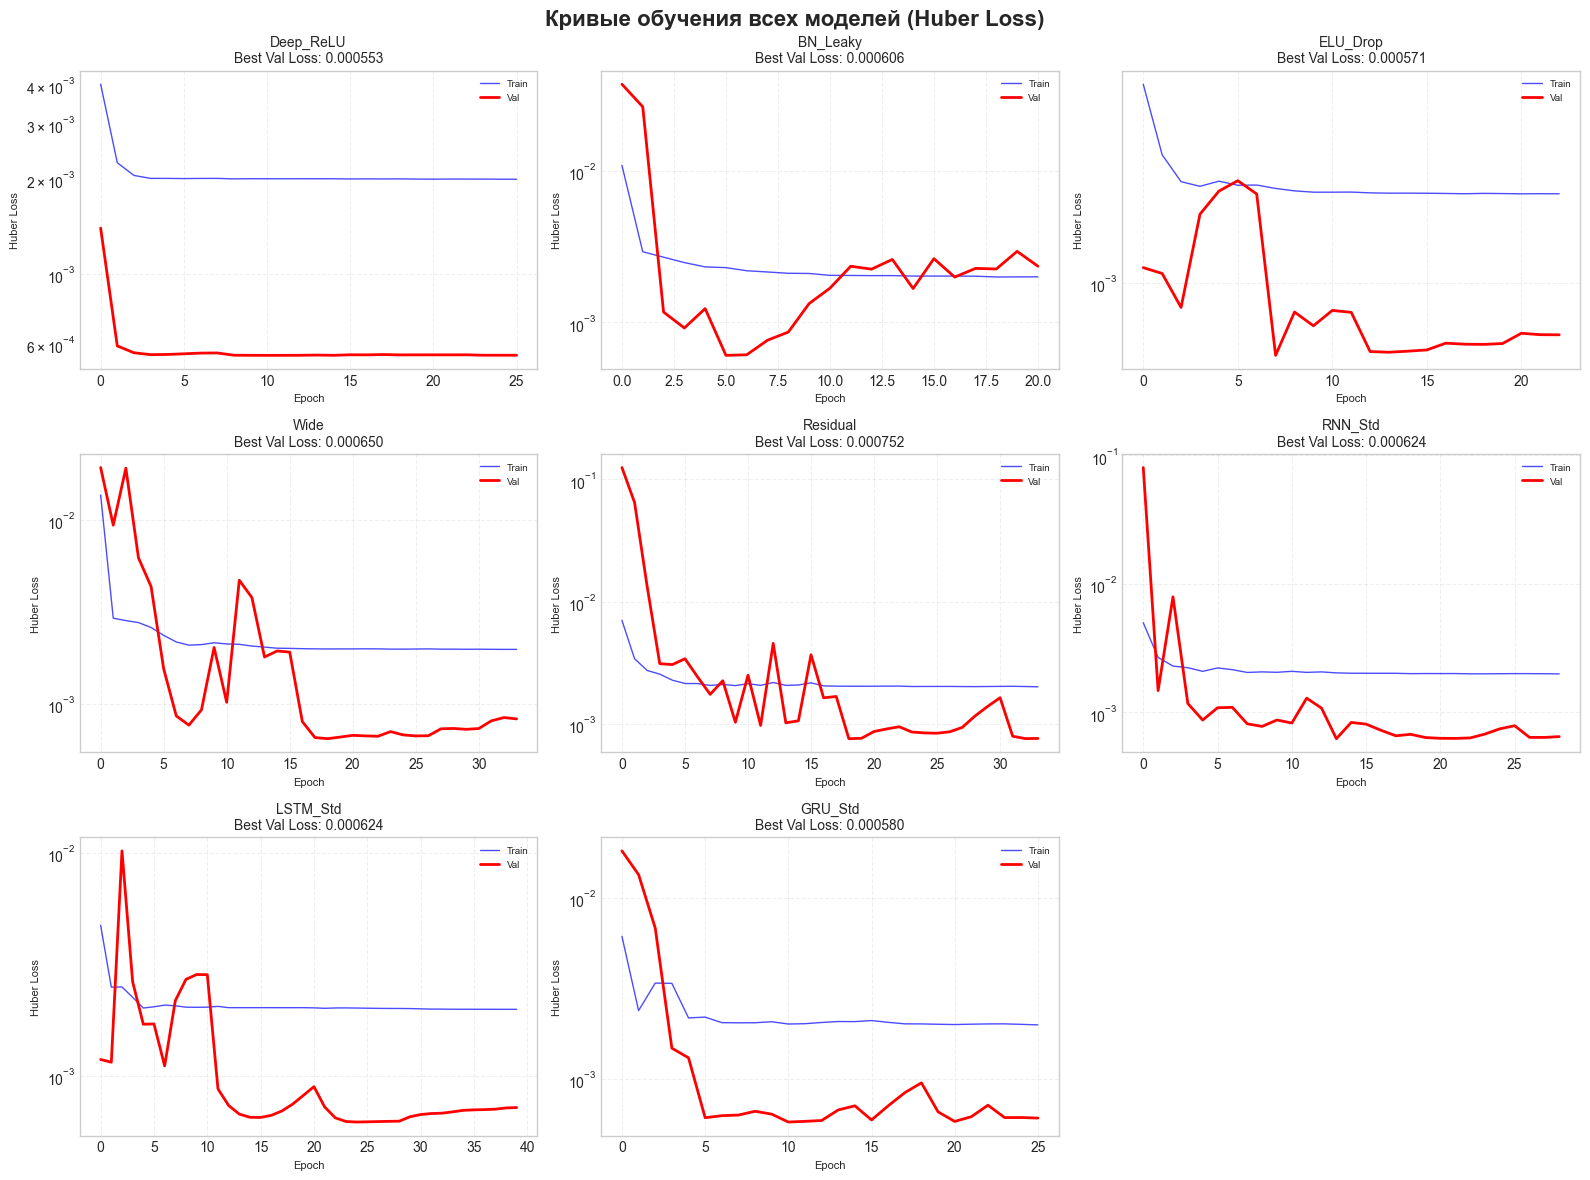

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 12))

for i, (name, data) in enumerate(results.items(), 1):
    history = data['history']
    plt.subplot(3, 3, i)  # Сетка 3×3 (9 мест) для 8 моделей
    
    # Рисуем кривые обучения
    plt.plot(history['train_loss'], label='Train', linewidth=1, color='blue', alpha=0.7)
    plt.plot(history['val_loss'], label='Val', linewidth=2, color='red')
    
    # Заголовок с лучшим результатом
    best_val = min(history['val_loss'])
    plt.title(f'{name}\nBest Val Loss: {best_val:.6f}', fontsize=10)
    
    # Подписи осей
    plt.xlabel('Epoch', fontsize=8)
    plt.ylabel('Huber Loss', fontsize=8)
    
    # Легенда и сетка
    plt.legend(fontsize=7)
    plt.grid(alpha=0.3, linestyle='--')
    
    # Масштаб оси Y: логарифмический лучше показывает динамику малых потерь
    plt.yscale('log')  

plt.suptitle('Кривые обучения всех моделей (Huber Loss)', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

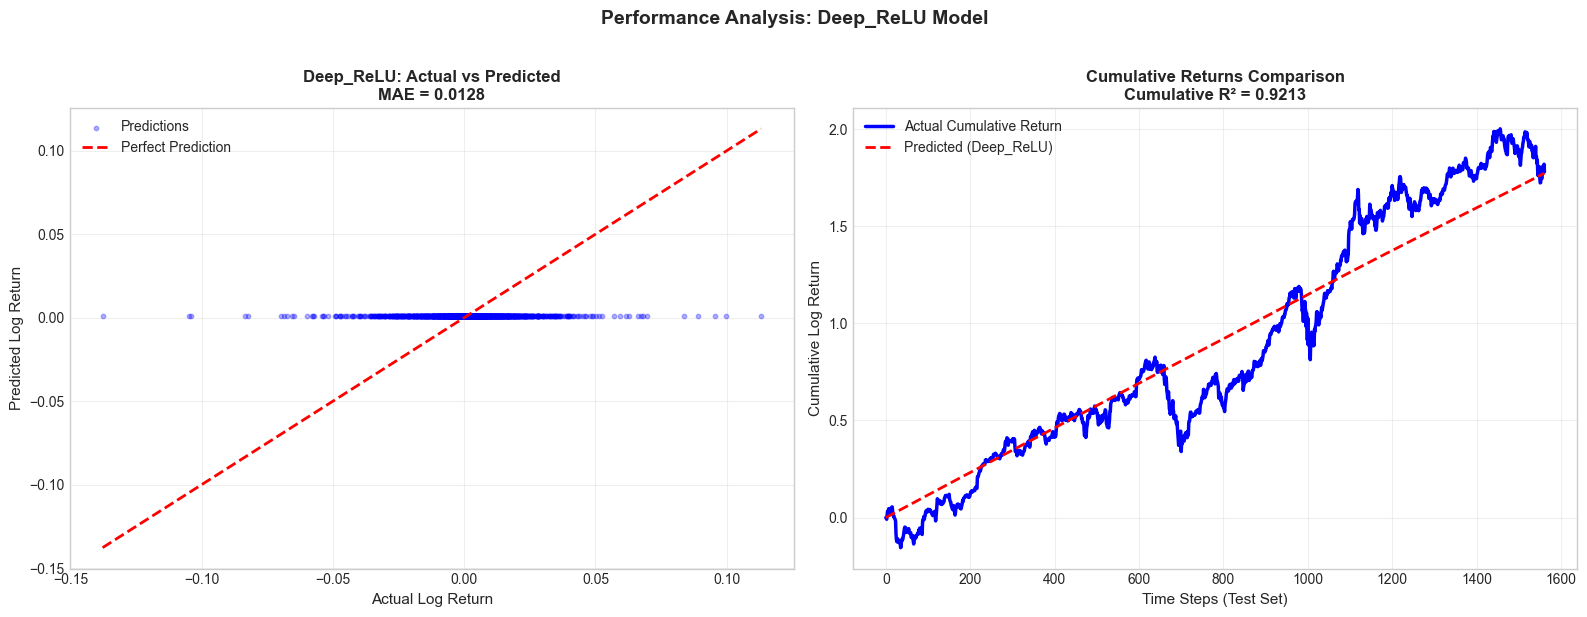

In [30]:
name = 'Deep_ReLU'
y_true = predictions_store[name]['y_true']
y_pred = predictions_store[name]['y_pred']

# Центрируем предсказание
bias = np.mean(y_pred) - np.mean(y_true)
y_pred_centered = y_pred - bias

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# === ГРАФИК 1: Actual vs Predicted ===
axes[0].scatter(y_true, y_pred, alpha=0.3, s=10, color='blue', label='Predictions')
axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Log Return', fontsize=11)
axes[0].set_ylabel('Predicted Log Return', fontsize=11)
axes[0].set_title(f'Deep_ReLU: Actual vs Predicted\nMAE = 0.0128', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# === ГРАФИК 2: Cumulative Returns ===
cum_true = np.cumsum(y_true)
cum_pred = np.cumsum(y_pred_centered)

# Нормализуем
cum_true = cum_true - cum_true[0]
cum_pred = cum_pred - cum_pred[0]

axes[1].plot(cum_true, label='Actual Cumulative Return', linewidth=2.5, color='blue')
axes[1].plot(cum_pred, label='Predicted (Deep_ReLU)', linewidth=2, color='red', linestyle='--')
axes[1].set_xlabel('Time Steps (Test Set)', fontsize=11)
axes[1].set_ylabel('Cumulative Log Return', fontsize=11)
axes[1].set_title(f'Cumulative Returns Comparison\nCumulative R² = 0.9213', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Performance Analysis: Deep_ReLU Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()